In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/janvijain96/cbf-cf/tensorflow2/default/1/cbf_cf_metrics.json
/kaggle/input/models/janvijain96/hybrid-embeddings/tensorflow2/default/1/hybrid_emb_metrics.json
/kaggle/input/models/janvijain96/hybrid/tensorflow2/default/1/hybrid_metrics.json
/kaggle/input/models/janvijain96/autoencoder/tensorflow2/default/1/autoencoder_metrics.json
/kaggle/input/models/janvijain96/dqn/tensorflow2/default/1/dqn_metrics.json


In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

print("Imports done")

Imports done


In [5]:
import json
import os

files = {
    'CBF+CF'           : '/kaggle/input/models/janvijain96/cbf-cf/tensorflow2/default/1/cbf_cf_metrics.json',
    'Autoencoder'      : '/kaggle/input/models/janvijain96/autoencoder/tensorflow2/default/1/autoencoder_metrics.json',
    'DQN'              : '/kaggle/input/models/janvijain96/dqn/tensorflow2/default/1/dqn_metrics.json',
    'Hybrid'           : '/kaggle/input/models/janvijain96/hybrid/tensorflow2/default/1/hybrid_metrics.json',
    'Hybrid+Embeddings': '/kaggle/input/models/janvijain96/hybrid-embeddings/tensorflow2/default/1/hybrid_emb_metrics.json'
}

for model_name, path in files.items():
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        print(f"\n{model_name}:")
        for k, v in data.items():
            print(f"  '{k}' : {v}")
    else:
        print(f"\n{model_name}: FILE NOT FOUND at {path}")


CBF+CF:
  'model' : CBF+CF
  'MAE_hybrid' : 0.5255
  'MSE_hybrid' : 0.3908
  'RMSE_hybrid' : 0.6252
  'MAE_cf_only' : 0.7464
  'MAE_cbf_only' : 0.3773
  'timing_seconds' : 1.12
  'paper_MAE' : 1.13
  'beats_paper' : True

Autoencoder:
  'model' : CF Autoencoder
  'best_config' : {'enc_units': [256, 128], 'latent_dim': 64, 'dropout': 0.2, 'lr': 0.001}
  'total_epochs' : 43
  'training_time' : 0:00:17
  'best_train_loss' : 0.0527
  'best_val_loss' : 0.0224
  'best_train_mae' : 0.1819
  'best_val_mae' : 0.0971
  'test_MAE' : 0.7861
  'test_MSE' : 0.7964
  'test_RMSE' : 0.8924
  'paper_MAE' : 3.05
  'beats_paper' : True

DQN:
  'model' : DQN
  'MAE' : 2.07
  'MSE' : 5.0363
  'RMSE' : 2.2442
  'training_time' : 0:07:58
  'total_steps' : 52500
  'final_epsilon' : 0.9851
  'avg_reward_ep' : -17385.3333
  'paper_MAE' : 3.22
  'beats_paper' : True

Hybrid:
  'model' : Hybrid Multi-Tower
  'best_config' : {'user_u': 128, 'item_u': 256, 'drop': 0.2, 'lr': 0.001}
  'total_epochs' : 200
  'trainin

In [6]:
import json
import os
import pandas as pd
import numpy as np

files = {
    'CBF+CF'           : '/kaggle/input/models/janvijain96/cbf-cf/tensorflow2/default/1/cbf_cf_metrics.json',
    'Autoencoder'      : '/kaggle/input/models/janvijain96/autoencoder/tensorflow2/default/1/autoencoder_metrics.json',
    'DQN'              : '/kaggle/input/models/janvijain96/dqn/tensorflow2/default/1/dqn_metrics.json',
    'Hybrid'           : '/kaggle/input/models/janvijain96/hybrid/tensorflow2/default/1/hybrid_metrics.json',
    'Hybrid+Embeddings': '/kaggle/input/models/janvijain96/hybrid-embeddings/tensorflow2/default/1/hybrid_emb_metrics.json'
}

# Paper values for reference
paper_values = {
    'CBF+CF'           : {'paper_MAE':1.13,  'paper_MSE':1.96,   'paper_RMSE':1.40},
    'Autoencoder'      : {'paper_MAE':3.05,  'paper_MSE':10.46,  'paper_RMSE':3.23},
    'DQN'              : {'paper_MAE':3.22,  'paper_MSE':12.22,  'paper_RMSE':3.49},
    'Hybrid'           : {'paper_MAE':0.11,  'paper_MSE':0.033,  'paper_RMSE':0.18},
    'Hybrid+Embeddings': {'paper_MAE':0.49,  'paper_MSE':0.36,   'paper_RMSE':0.60},
}

def extract_value(data, possible_keys):
    """
    Try multiple key names and return the first one found.
    This handles inconsistent key names across different save cells.
    """
    for key in possible_keys:
        if key in data:
            return float(data[key])
    return None

all_data = []

for model_name, path in files.items():
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)

        # MAE — try all possible key names
        mae = extract_value(data, [
            'MAE', 'test_MAE', 'MAE_hybrid',
            'mae', 'test_mae', 'val_mae'
        ])

        # MSE — try all possible key names
        mse = extract_value(data, [
            'MSE', 'test_MSE', 'MSE_hybrid',
            'mse', 'test_mse', 'val_mse'
        ])

        # RMSE — try all possible key names
        rmse = extract_value(data, [
            'RMSE', 'test_RMSE', 'RMSE_hybrid',
            'rmse', 'test_rmse', 'val_rmse'
        ])

        row = {
            'model'     : model_name,
            'MAE'       : mae,
            'MSE'       : mse,
            'RMSE'      : rmse,
            'paper_MAE' : paper_values[model_name]['paper_MAE'],
            'paper_MSE' : paper_values[model_name]['paper_MSE'],
            'paper_RMSE': paper_values[model_name]['paper_RMSE'],
        }
        all_data.append(row)
        print(f"✅ Loaded : {model_name} → MAE={mae} | MSE={mse} | RMSE={rmse}")

    else:
        print(f"❌ Missing: {model_name} at {path}")

results_all = pd.DataFrame(all_data)
print(f"\nLoaded {len(results_all)} models successfully")
print(results_all.to_string(index=False))

✅ Loaded : CBF+CF → MAE=0.5255 | MSE=0.3908 | RMSE=0.6252
✅ Loaded : Autoencoder → MAE=0.7861 | MSE=0.7964 | RMSE=0.8924
✅ Loaded : DQN → MAE=2.07 | MSE=5.0363 | RMSE=2.2442
✅ Loaded : Hybrid → MAE=0.0803 | MSE=0.0254 | RMSE=0.1595
✅ Loaded : Hybrid+Embeddings → MAE=0.3408 | MSE=0.2496 | RMSE=0.4996

Loaded 5 models successfully
            model    MAE    MSE   RMSE  paper_MAE  paper_MSE  paper_RMSE
           CBF+CF 0.5255 0.3908 0.6252       1.13      1.960        1.40
      Autoencoder 0.7861 0.7964 0.8924       3.05     10.460        3.23
              DQN 2.0700 5.0363 2.2442       3.22     12.220        3.49
           Hybrid 0.0803 0.0254 0.1595       0.11      0.033        0.18
Hybrid+Embeddings 0.3408 0.2496 0.4996       0.49      0.360        0.60


In [7]:
print("\n" + "="*80)
print("  FULL COMPARISON: ALL MODELS vs PAPER")
print("="*80)
print(f"{'Model':<25}{'Our MAE':>10}{'Paper MAE':>12}"
      f"{'Our MSE':>10}{'Paper MSE':>12}{'Beats?':>8}")
print("-"*80)

for _, r in results_all.iterrows():
    beats = "YES" if r['MAE'] < r['paper_MAE'] else "no"
    print(f"  {r['model']:<23}"
          f"{r['MAE']:>10.4f}"
          f"{r['paper_MAE']:>12.2f}"
          f"{r['MSE']:>10.4f}"
          f"{r['paper_MSE']:>12.3f}"
          f"{beats:>8}")

print("="*80)

beats_count = sum(
    1 for _, r in results_all.iterrows()
    if r['MAE'] < r['paper_MAE']
)
print(f"\n  Models beating paper: {beats_count}/{len(results_all)}")


  FULL COMPARISON: ALL MODELS vs PAPER
Model                       Our MAE   Paper MAE   Our MSE   Paper MSE  Beats?
--------------------------------------------------------------------------------
  CBF+CF                     0.5255        1.13    0.3908       1.960     YES
  Autoencoder                0.7861        3.05    0.7964      10.460     YES
  DQN                        2.0700        3.22    5.0363      12.220     YES
  Hybrid                     0.0803        0.11    0.0254       0.033     YES
  Hybrid+Embeddings          0.3408        0.49    0.2496       0.360     YES

  Models beating paper: 5/5


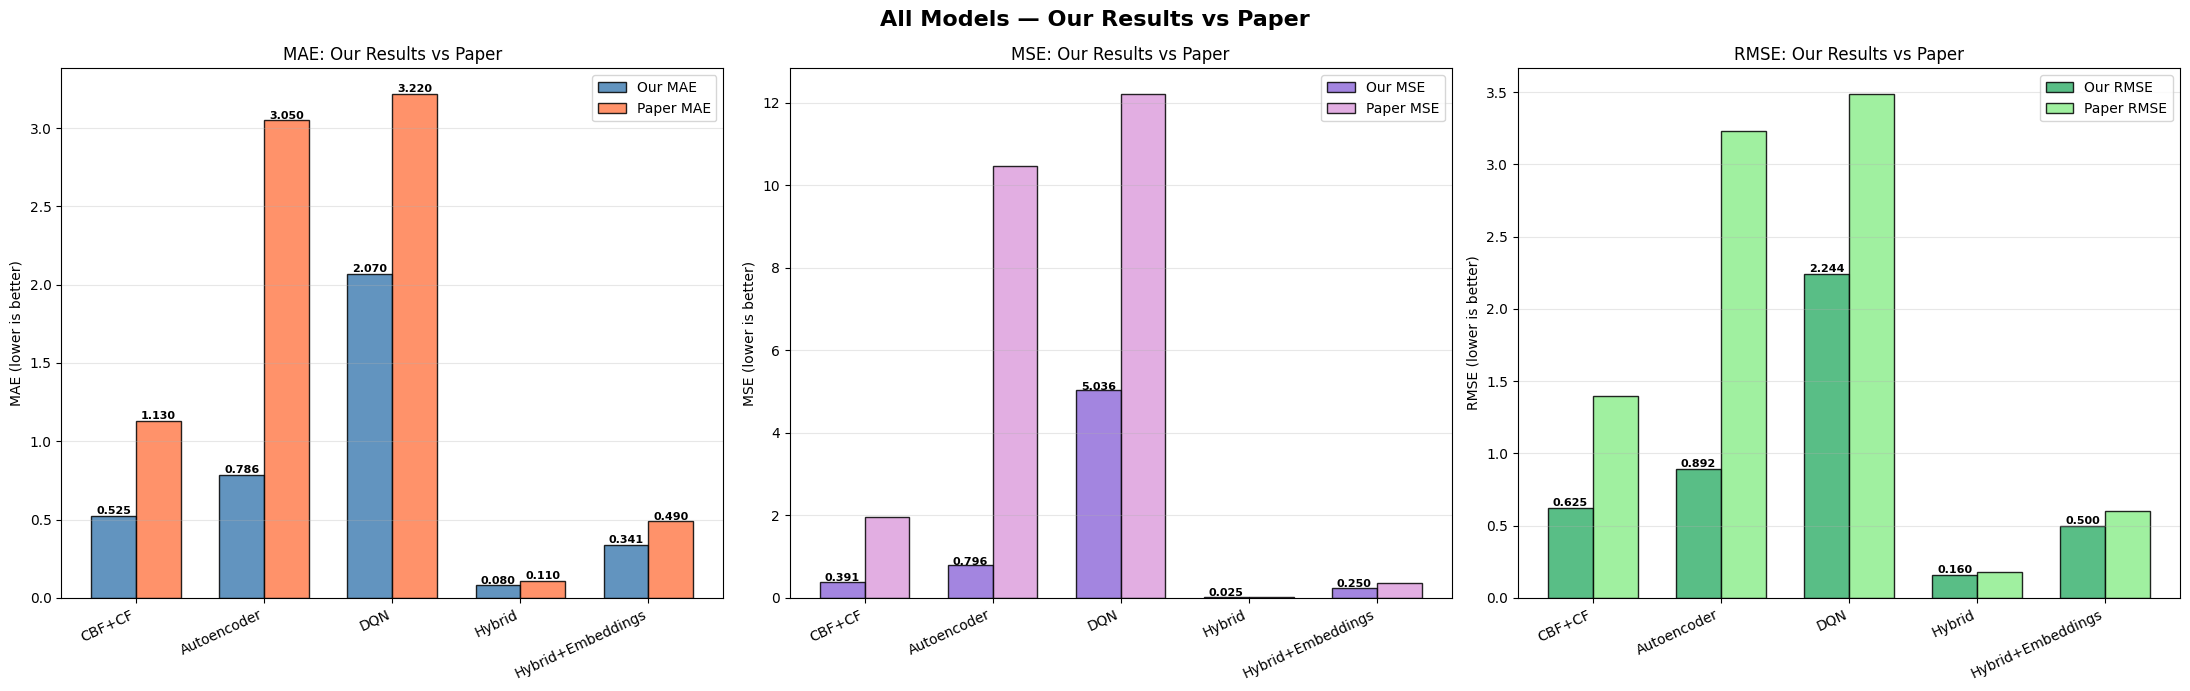


Beats Paper Summary:
  ✅ YES  CBF+CF                 better by 0.6045
  ✅ YES  Autoencoder            better by 2.2639
  ✅ YES  DQN                    better by 1.1500
  ✅ YES  Hybrid                 better by 0.0297
  ✅ YES  Hybrid+Embeddings      better by 0.1492


In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('All Models — Our Results vs Paper',
             fontsize=16, fontweight='bold')

models     = results_all['model'].tolist()
our_mae    = results_all['MAE'].tolist()
our_mse    = results_all['MSE'].tolist()
our_rmse   = results_all['RMSE'].tolist()
paper_mae  = results_all['paper_MAE'].tolist()
paper_mse  = results_all['paper_MSE'].tolist()
paper_rmse = results_all['paper_RMSE'].tolist()

x = np.arange(len(models))
w = 0.35

# Plot 1: MAE
b1 = axes[0].bar(x - w/2, our_mae,  width=w,
                  label='Our MAE',   color='steelblue',
                  edgecolor='black', alpha=0.85)
b2 = axes[0].bar(x + w/2, paper_mae, width=w,
                  label='Paper MAE', color='coral',
                  edgecolor='black', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=25, ha='right')
axes[0].set_ylabel('MAE (lower is better)')
axes[0].set_title('MAE: Our Results vs Paper')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for bar in b1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}',
                 ha='center', fontsize=8, fontweight='bold')
for bar in b2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}',
                 ha='center', fontsize=8, fontweight='bold')

# Plot 2: MSE
b3 = axes[1].bar(x - w/2, our_mse,   width=w,
                  label='Our MSE',   color='mediumpurple',
                  edgecolor='black', alpha=0.85)
b4 = axes[1].bar(x + w/2, paper_mse, width=w,
                  label='Paper MSE', color='plum',
                  edgecolor='black', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=25, ha='right')
axes[1].set_ylabel('MSE (lower is better)')
axes[1].set_title('MSE: Our Results vs Paper')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for bar in b3:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}',
                 ha='center', fontsize=8, fontweight='bold')

# Plot 3: RMSE
b5 = axes[2].bar(x - w/2, our_rmse,   width=w,
                  label='Our RMSE',   color='mediumseagreen',
                  edgecolor='black',  alpha=0.85)
b6 = axes[2].bar(x + w/2, paper_rmse, width=w,
                  label='Paper RMSE', color='lightgreen',
                  edgecolor='black',  alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=25, ha='right')
axes[2].set_ylabel('RMSE (lower is better)')
axes[2].set_title('RMSE: Our Results vs Paper')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')
for bar in b5:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}',
                 ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBeats Paper Summary:")
print("="*45)
for _, r in results_all.iterrows():
    beats  = r['MAE'] < r['paper_MAE']
    symbol = "✅ YES" if beats else "❌ no"
    diff   = r['paper_MAE'] - r['MAE']
    msg    = f"better by {diff:.4f}" if beats else f"worse by {abs(diff):.4f}"
    print(f"  {symbol}  {r['model']:<22} {msg}")
print("="*45)